### Machine Learning for Regression

In [1]:
import numpy as np
import pandas as pd

In [2]:
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'

In [3]:
!wget $data

--2026-10-06 20:58:43--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.003s  

2026-10-06 20:58:43 (236 MB/s) - ‘car_fuel_efficiency_2026.csv’ saved [635180/635180]



In [4]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')

In [5]:
#Accessing dtypes str values using index method as list

strings = list(df.dtypes[df.dtypes == 'str'].index)
strings

['origin', 'fuel_type', 'drivetrain']

In [6]:
#cleaning data and writing back to each column
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [7]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,europe,gasoline,front-wheel_drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,europe,diesel,front-wheel_drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,asia,gasoline,front-wheel_drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,europe,gasoline,front-wheel_drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,usa,diesel,front-wheel_drive,3,2580,7,304.0,4510,17.5,31.0


In [8]:
df2 = df[
    ['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']
    ]
df2.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


### Exploratory Data Analysis

In [9]:
df = df2.copy()

In [10]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

engine_displacement
[2180 2390 2320 2130 2580]
127

horsepower
[243. 272. 267. 258. 304.]
153

vehicle_weight
[3870 4210 4240 4490 4510]
176

model_year
[2006 2008 1996 1989 1994]
50

fuel_efficiency_mpg
[31.9 31.3 27.5 28.5 31. ]
188



**Distribution of Fuel Efficiency**

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

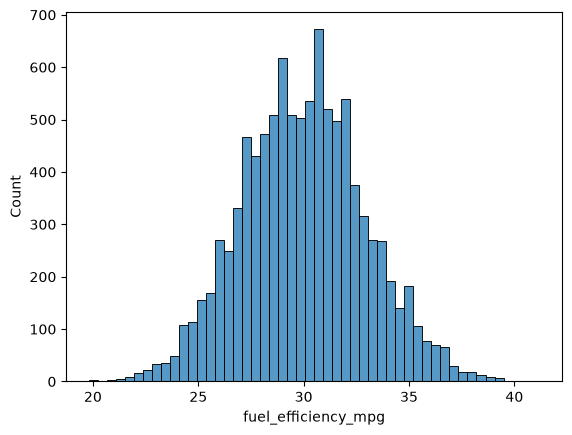

In [12]:
sns.histplot(df2["fuel_efficiency_mpg"], bins=50)

### Qestion 1

In [13]:
#Column with missing values
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

### Question 2

In [14]:
#The median (50% percentile) for variable 'horsepower'
df2["horsepower"].median()

np.float64(254.0)

**Dataset split**

In [15]:
#splitting rule
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [16]:
#Shuffling dataset
np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

In [17]:
#Splitting dataset
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [18]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
6252,1900,239.0,3790,2015,32.5
4684,2000,224.0,4380,1992,29.1
1731,2330,286.0,4090,2022,34.1
4742,2300,NaN,4150,1997,30.6
4521,2340,269.0,4400,2001,30.7


In [19]:
#Resetting index
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [20]:
len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

### Question 3

**(A) Filling missing values in column 'horsepower' with 0**

In [21]:
df_trainA = df_train.copy()
df_valA = df_val.copy()
df_testA = df_test.copy()

In [22]:
df_trainA["horsepower"] = df_trainA["horsepower"].fillna(0)

In [23]:
df_trainA.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,1900,239.0,3790,2015,32.5
1,2000,224.0,4380,1992,29.1
2,2330,286.0,4090,2022,34.1
3,2300,0.0,4150,1997,30.6
4,2340,269.0,4400,2001,30.7


In [24]:
y_trainA = df_train["fuel_efficiency_mpg"].values
y_valA = df_val["fuel_efficiency_mpg"].values
y_testA = df_test["fuel_efficiency_mpg"].values

In [25]:
del df_trainA["fuel_efficiency_mpg"]
del df_valA["fuel_efficiency_mpg"]
del df_testA["fuel_efficiency_mpg"]

In [26]:
len(y_trainA)

6000

In [27]:
df_trainA.head()

,engine_displacement,horsepower,vehicle_weight,model_year
0,1900,239.0,3790,2015
1,2000,224.0,4380,1992
2,2330,286.0,4090,2022
3,2300,0.0,4150,1997
4,2340,269.0,4400,2001


**(Ai) Training linear regression model**

In [28]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [29]:
X_trainA = df_trainA.values
X_trainA

array([[1900.,  239., 3790., 2015.],
       [2000.,  224., 4380., 1992.],
       [2330.,  286., 4090., 2022.],
       ...,
       [2240.,  255., 4190., 1989.],
       [2430.,  254., 4280., 2020.],
       [2390.,  266., 4220., 1996.]], shape=(6000, 4))

In [30]:
y_trainA

array([32.5, 29.1, 34.1, ..., 27.7, 31.6, 28. ], shape=(6000,))

In [31]:
w0, w = train_linear_regression(X_trainA, y_trainA)

In [32]:
w0

np.float64(-153.88496188223104)

In [33]:
w

array([-1.51505520e-03, -4.74024794e-06, -3.95418397e-03,  1.02146785e-01])

In [34]:
#Prediction
y_predA = w0 + X_trainA.dot(w)

<Axes: ylabel='Count'>

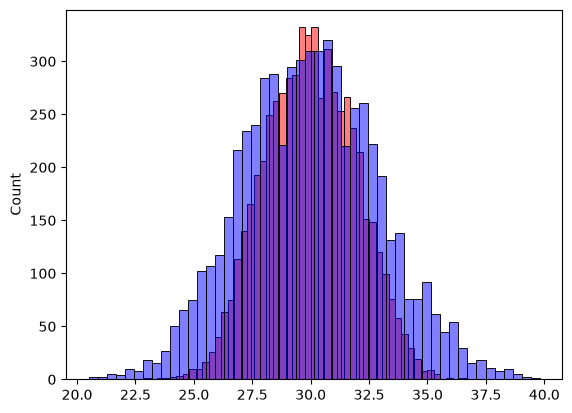

In [35]:
#Plot
sns.histplot(y_predA, color='red', alpha=0.5, bins=50)
sns.histplot(y_trainA, color='blue', alpha=0.5, bins=50)

**(Aii) Validating the model**

In [36]:
df_valA.isnull().sum()

engine_displacement      0
horsepower             176
vehicle_weight           0
model_year               0
dtype: int64

In [37]:
def prepare_X(df):
    df["horsepower"] = df["horsepower"].fillna(0)
    X = df.values
    return X

In [38]:
X_valA = prepare_X(df_valA)
X_valA

array([[2240.,  265., 3990., 2004.],
       [2390.,  259., 4770., 2019.],
       [2360.,  265., 4320., 2018.],
       ...,
       [2390.,  264., 4550., 2017.],
       [2330.,  244., 4440., 2014.],
       [2170.,  260., 4460., 2021.]], shape=(2000, 4))

In [39]:
y_valA

array([30.4, 32.8, 27.8, ..., 30.6, 31. , 30.8], shape=(2000,))

In [40]:
#Training
w0, w = train_linear_regression(X_valA, y_valA)

In [41]:
w0

np.float64(-155.9810314669499)

In [42]:
w

array([-0.00087544, -0.0016548 , -0.00400707,  0.10280457])

In [43]:
#Predition
y_predA = w0 + X_valA.dot(w)
y_predA

array([31.65163055, 29.94680012, 31.66350999, ..., 30.61447171,
       30.83245759, 31.58554139], shape=(2000,))

<Axes: ylabel='Count'>

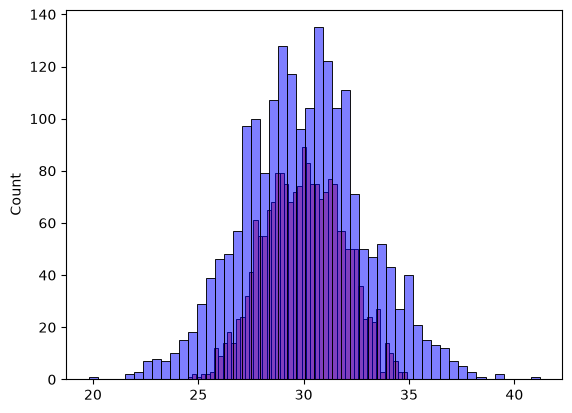

In [44]:
#Plot
sns.histplot(y_predA, color='red', alpha=0.5, bins=50)
sns.histplot(y_valA, color='blue', alpha=0.5, bins=50)

**(Aiv) RMSE**

In [45]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [46]:
round(rmse(y_valA, y_predA), 3)

np.float64(2.2)

**(B) Filling missing values in column 'horsepower' with column mean**

In [47]:
df_trainB = df_train.copy()
df_valB = df_val.copy()
df_testB = df_test.copy()

In [48]:
y_trainB = df_train["fuel_efficiency_mpg"].values
y_valB = df_val["fuel_efficiency_mpg"].values
y_testB = df_test["fuel_efficiency_mpg"].values

In [49]:
del df_trainB["fuel_efficiency_mpg"]
del df_valB["fuel_efficiency_mpg"]
del df_testB["fuel_efficiency_mpg"]

In [50]:
df_trainB.isnull().sum()

engine_displacement      0
horsepower             538
vehicle_weight           0
model_year               0
dtype: int64

In [51]:
def prepare_X(df):
    df["horsepower"] = df["horsepower"].fillna(df["horsepower"].mean())
    X = df.values
    return X

In [52]:
X_trainB = prepare_X(df_trainB)
X_trainB

array([[1900.,  239., 3790., 2015.],
       [2000.,  224., 4380., 1992.],
       [2330.,  286., 4090., 2022.],
       ...,
       [2240.,  255., 4190., 1989.],
       [2430.,  254., 4280., 2020.],
       [2390.,  266., 4220., 1996.]], shape=(6000, 4))

In [53]:
y_trainB

array([32.5, 29.1, 34.1, ..., 27.7, 31.6, 28. ], shape=(6000,))

In [54]:
#Training
w0, w = train_linear_regression(X_trainB, y_trainB)

In [55]:
w0

np.float64(-153.29645639182718)

In [56]:
w

array([-0.00102386, -0.00648622, -0.00388828,  0.10197897])

In [57]:
#Prediction
y_predB = w0 + X_trainB.dot(w)

<Axes: ylabel='Count'>

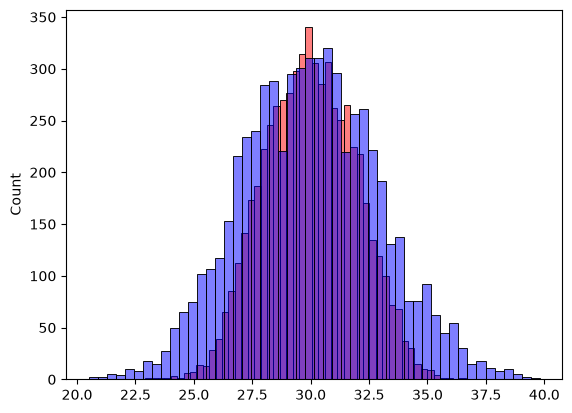

In [58]:
#Plot
sns.histplot(y_predB, color='red', alpha=0.5, bins=50)
sns.histplot(y_trainB, color='blue', alpha=0.5, bins=50)

**(Bi) Validating the model**

In [59]:
df_valB.isnull().sum()

engine_displacement      0
horsepower             176
vehicle_weight           0
model_year               0
dtype: int64

In [60]:
X_valB = prepare_X(df_valB)
X_valB

array([[2240.,  265., 3990., 2004.],
       [2390.,  259., 4770., 2019.],
       [2360.,  265., 4320., 2018.],
       ...,
       [2390.,  264., 4550., 2017.],
       [2330.,  244., 4440., 2014.],
       [2170.,  260., 4460., 2021.]], shape=(2000, 4))

In [61]:
y_valB

array([30.4, 32.8, 27.8, ..., 30.6, 31. , 30.8], shape=(2000,))

In [62]:
#Training
w0, w = train_linear_regression(X_valA, y_valA)

In [63]:
w0

np.float64(-155.9810314669499)

In [64]:
w

array([-0.00087544, -0.0016548 , -0.00400707,  0.10280457])

In [65]:
#Predition
y_predB = w0 + X_valB.dot(w)
y_predB

array([31.65163055, 29.94680012, 31.66350999, ..., 30.61447171,
       30.83245759, 31.58554139], shape=(2000,))

<Axes: ylabel='Count'>

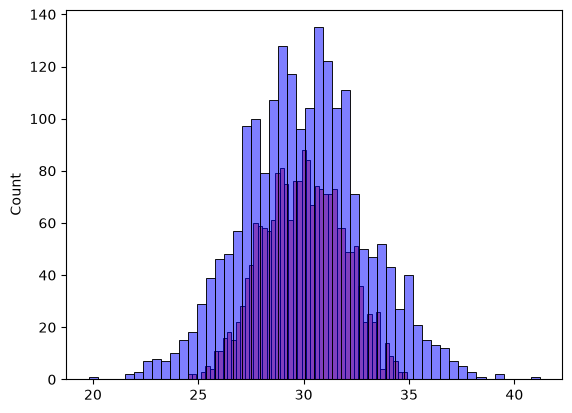

In [66]:
#Plot
sns.histplot(y_predB, color='red', alpha=0.5, bins=50)
sns.histplot(y_valB, color='blue', alpha=0.5, bins=50)

**(Bii) RMSE**

In [67]:
round(rmse(y_valB, y_predB), 3)

np.float64(2.202)

### Question 4

**Regularized linear regression**

In [68]:
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [69]:
def prepare_X(df):
    df["horsepower"] = df["horsepower"].fillna(0)
    X = df.values
    return X

In [70]:
y_train = df_train["fuel_efficiency_mpg"].values
y_val = df_val["fuel_efficiency_mpg"].values
y_test = df_test["fuel_efficiency_mpg"].values

In [71]:
del df_train["fuel_efficiency_mpg"]
del df_val["fuel_efficiency_mpg"]
del df_test["fuel_efficiency_mpg"]

In [72]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = round(rmse(y_val, y_pred), 4)
    
    print(r, w0, score)

0 -153.88496188223104 2.2053
0.01 -148.3092124404723 2.2058
0.1 -111.83871039307081 2.2241
1 -32.331865964969374 2.3492
5 -7.772852209978469 2.4094
10 -3.987116416019025 2.4195
100 -0.4082196488463344 2.4292


## Question 5

In [73]:
df = df2.copy()

In [74]:
def prepare_X(df):
    df["horsepower"] = df["horsepower"].fillna(0)
    X = df.values
    return X

In [75]:
scores = []
 
for seed in range(10):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test
    
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)


    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    
    y_train = df_train["fuel_efficiency_mpg"].values
    y_val = df_val["fuel_efficiency_mpg"].values
    y_test = df_test["fuel_efficiency_mpg"].values
    
    del df_train["fuel_efficiency_mpg"]
    del df_val["fuel_efficiency_mpg"]
    del df_test["fuel_efficiency_mpg"]
        
    # train model
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression(X_train, y_train)
    
    # prediction
    y_pred = w0 + X_val.dot(w)
    
    # validation RMSE
    score = rmse(y_val, y_pred)
    scores.append(score)
    
std = np.std(scores)
 
print('RMSE scores:', scores)
print('Standard deviation:', round(std, 3))

RMSE scores: [np.float64(3.5184522588258544), np.float64(3.4879857636090463), np.float64(3.395111045487282), np.float64(3.5199515715931837), np.float64(3.4403886475451793), np.float64(3.544270743114748), np.float64(3.5487116807470565), np.float64(3.4539265506362886), np.float64(3.5441770005041437), np.float64(3.449647289393668)]
Standard deviation: 0.05


### Question 6

In [76]:
# split data
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [77]:
# combine train and validation
df_full_train = pd.concat([df_train, df_val])

y_full_train = df_full_train["fuel_efficiency_mpg"].values
y_test = df_test["fuel_efficiency_mpg"].values

del df_full_train["fuel_efficiency_mpg"]
del df_test["fuel_efficiency_mpg"]

In [78]:
# prepare features (fills missing values with 0)
X_full_train = prepare_X(df_full_train)
X_test = prepare_X(df_test)

In [79]:
# train model with regularization
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

In [80]:
w0

np.float64(-152.37535772493302)

In [81]:
w

array([-0.00135534, -0.00042645, -0.00401765,  0.10140402])

In [82]:
# predict on test set
y_pred = w0 + X_test.dot(w)

In [83]:
# RMSE
rmse_test = round(rmse(y_test, y_pred), 3)
rmse_test

np.float64(2.236)